# ESCI Search Relevance — Exploratory Data Analysis

**Dataset**: Amazon ESCI (Explicit Semantic Context Information)  
**Project**: `reddit-search-relevance-485717` · BigQuery `esci_search`  
**Purpose**: Understand data distribution, label skew, query/product quality, and BM25 signal strength before training ColBERT + LambdaMART.

| Section | Question answered |
|---|---|
| 1. Dataset Scale | How big is this? What are the splits? |
| 2. Relevance Labels | How skewed is the distribution? |
| 3. Query Analysis | What do queries look like? How long? |
| 4. Product Catalog | Field quality, title length, missing data |
| 5. Locale & Language | Is it multilingual? Does label mix differ? |
| 6. BM25 Baseline Signal | Does keyword overlap actually correlate with relevance? |
| 7. Query Difficulty | Are some queries structurally harder to rank? |
| 8. Key Findings | What does this mean for modeling decisions? |

In [1]:
import os
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.patches as mpatches
import seaborn as sns
from google.cloud import bigquery
from rank_bm25 import BM25Okapi

os.makedirs('figures', exist_ok=True)

PROJECT  = 'reddit-search-relevance-485717'
DATASET  = 'esci_search'
EX       = f'`{PROJECT}.{DATASET}.examples`'
PR       = f'`{PROJECT}.{DATASET}.products`'

client = bigquery.Client(project=PROJECT)

# ── Design system ──────────────────────────────────────────────────────────────
LABEL_ORDER  = ['E', 'S', 'C', 'I']
LABEL_COLORS = {'E': '#27ae60', 'S': '#f39c12', 'C': '#2980b9', 'I': '#e74c3c'}
LABEL_NAMES  = {'E': 'Exact', 'S': 'Substitute', 'C': 'Complement', 'I': 'Irrelevant'}
PALETTE      = ['#2c3e50', '#2980b9', '#27ae60', '#e74c3c', '#f39c12', '#8e44ad']

plt.rcParams.update({
    'figure.dpi': 130,
    'font.family': 'sans-serif',
    'font.size': 11,
    'axes.titlesize': 13,
    'axes.labelsize': 11,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'grid.alpha': 0.3,
    'figure.facecolor': 'white',
})
sns.set_palette(PALETTE)

def q(sql):  return client.query(sql).to_dataframe()
def fmt(n):  return f'{int(n):,}'

print('BigQuery connected ✓')

BigQuery connected ✓


---
## 1. Dataset at a Glance

I0000 00:00:1777069413.434152 52201848 check_gcp_environment_no_op.cc:29] ALTS: Platforms other than Linux and Windows are not supported


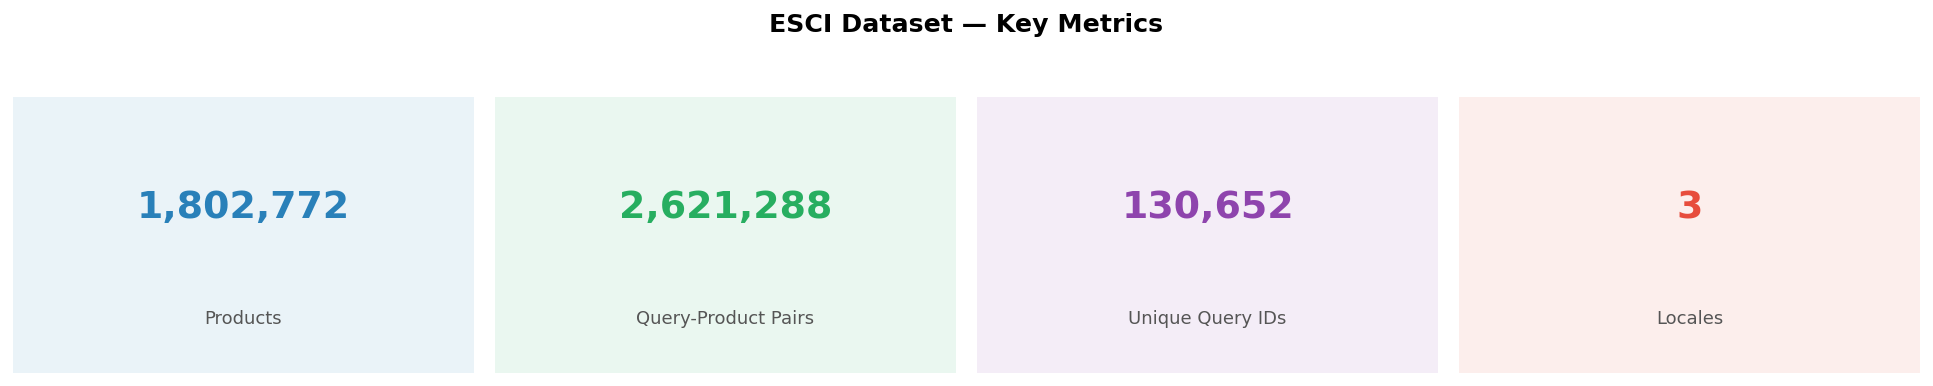

Avg gain across all pairs:  0.6738
Unique query strings:        130,193


In [2]:
overview = q(f"""
SELECT
    (SELECT COUNT(DISTINCT product_id) FROM {PR})         AS n_products,
    (SELECT COUNT(*)                  FROM {EX})          AS n_examples,
    (SELECT COUNT(DISTINCT query_id)  FROM {EX})          AS n_queries,
    (SELECT COUNT(DISTINCT query)     FROM {EX})          AS n_unique_queries,
    (SELECT COUNT(DISTINCT product_locale) FROM {EX})     AS n_locales,
    (SELECT ROUND(AVG(gain), 4)       FROM {EX})          AS avg_gain
""")

kpis = [
    ('Products',             fmt(overview['n_products'].iloc[0]),      '#2980b9'),
    ('Query-Product Pairs',  fmt(overview['n_examples'].iloc[0]),      '#27ae60'),
    ('Unique Query IDs',     fmt(overview['n_queries'].iloc[0]),       '#8e44ad'),
    ('Locales',              str(int(overview['n_locales'].iloc[0])),  '#e74c3c'),
]

fig, axes = plt.subplots(1, 4, figsize=(15, 2.8))
for ax, (label, value, color) in zip(axes, kpis):
    ax.set_facecolor(color + '18')
    ax.text(0.5, 0.60, value, ha='center', va='center', fontsize=21,
            fontweight='bold', color=color, transform=ax.transAxes)
    ax.text(0.5, 0.20, label, ha='center', va='center', fontsize=10,
            color='#555', transform=ax.transAxes)
    for s in ax.spines.values(): s.set_visible(False)
    ax.set_xticks([]); ax.set_yticks([])

fig.suptitle('ESCI Dataset — Key Metrics', fontsize=14, fontweight='bold', y=1.05)
plt.tight_layout()
plt.savefig('figures/00_kpi_cards.png', bbox_inches='tight')
plt.show()

print(f"Avg gain across all pairs:  {overview['avg_gain'].iloc[0]:.4f}")
print(f"Unique query strings:        {fmt(overview['n_unique_queries'].iloc[0])}")

I0000 00:00:1777069416.689738 52201848 check_gcp_environment_no_op.cc:29] ALTS: Platforms other than Linux and Windows are not supported


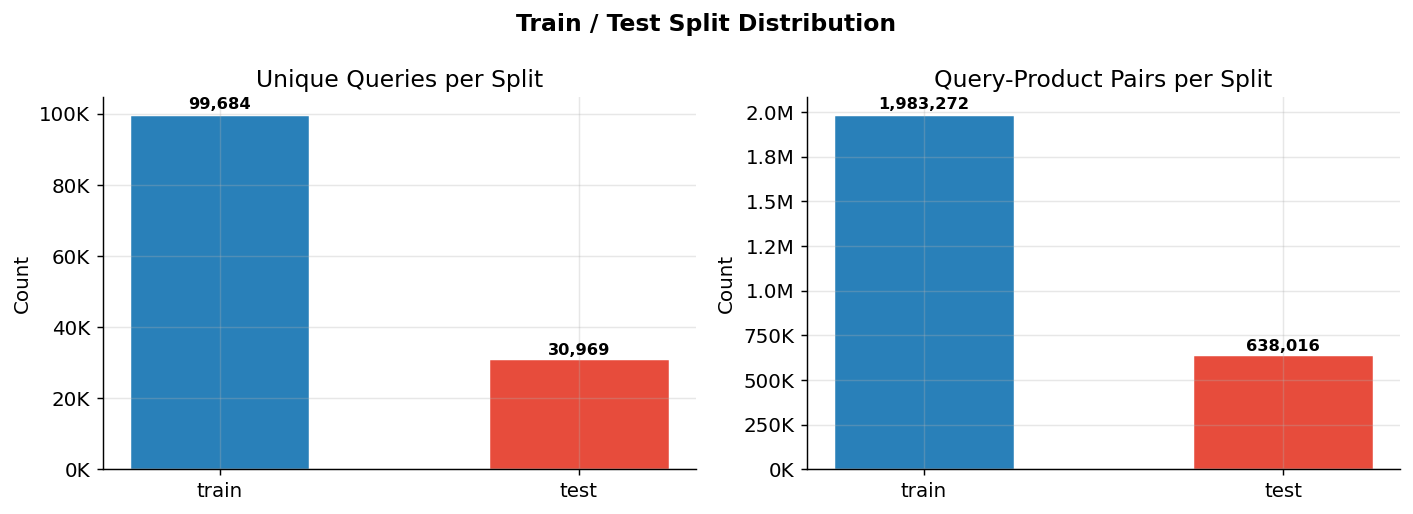

split  n_queries  n_examples
train      99684     1983272
 test      30969      638016


In [3]:
splits = q(f"""
SELECT
    split,
    COUNT(DISTINCT query_id) AS n_queries,
    COUNT(*)                 AS n_examples
FROM {EX}
GROUP BY split
ORDER BY n_queries DESC
""")

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
colors = ['#2980b9', '#e74c3c', '#27ae60']

for ax, col, title in zip(axes,
                          ['n_queries', 'n_examples'],
                          ['Unique Queries per Split', 'Query-Product Pairs per Split']):
    bars = ax.bar(splits['split'], splits[col], color=colors[:len(splits)],
                  edgecolor='white', linewidth=0.8, width=0.5)
    ax.set_title(title)
    ax.set_ylabel('Count')
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e3:.0f}K' if x < 1e6 else f'{x/1e6:.1f}M'))
    for bar, val in zip(bars, splits[col]):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() * 1.01,
                fmt(val), ha='center', va='bottom', fontsize=9, fontweight='bold')

fig.suptitle('Train / Test Split Distribution', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('figures/01_split_distribution.png', bbox_inches='tight')
plt.show()
print(splits.to_string(index=False))

---
## 2. Relevance Label Distribution

ESCI grades each (query, product) pair on four levels:

| Label | Name | Gain | Meaning |
|---|---|---|---|
| **E** | Exact | 1.0 | Product directly satisfies the query |
| **S** | Substitute | 0.1 | Similar but not exactly what was searched |
| **C** | Complement | 0.01 | Used together with what was searched |
| **I** | Irrelevant | 0.0 | No meaningful relation |

Label skew governs hard negative mining strategy and loss weighting.

I0000 00:00:1777069419.341417 52201848 check_gcp_environment_no_op.cc:29] ALTS: Platforms other than Linux and Windows are not supported


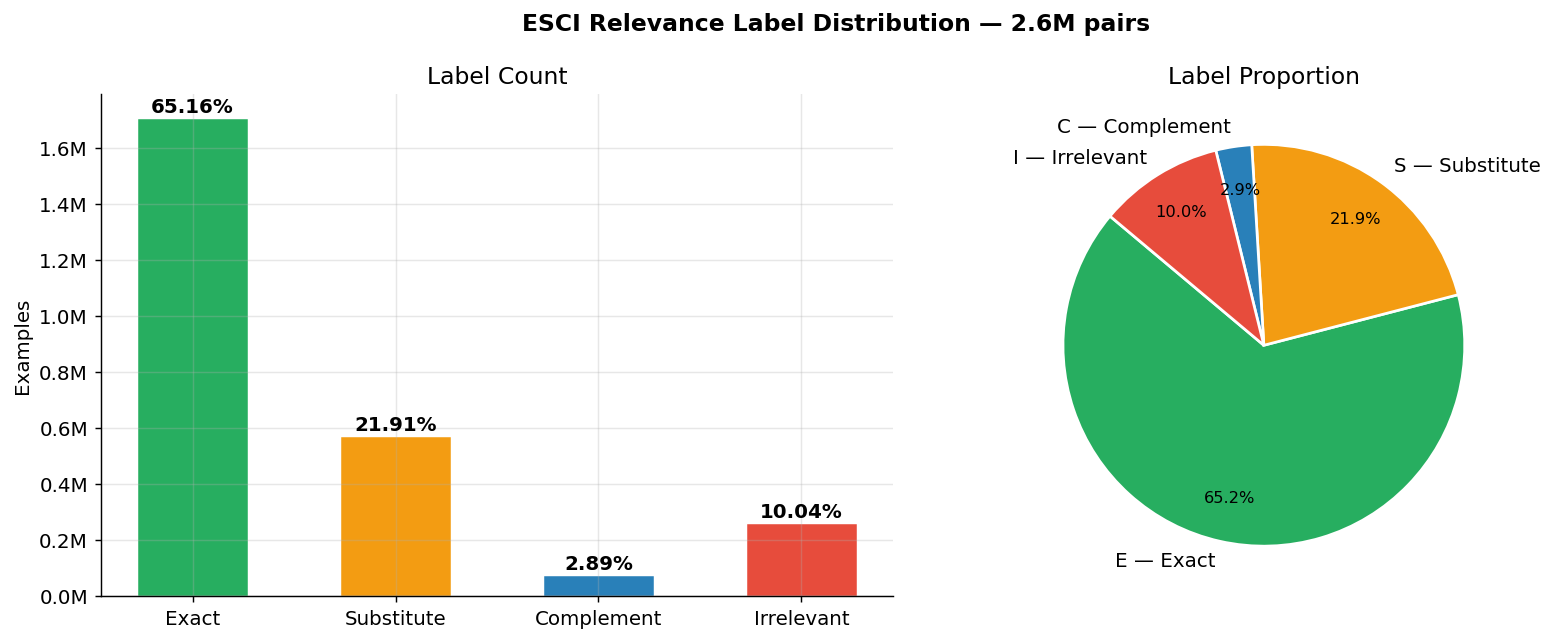

esci_label label_name     cnt   pct  avg_gain
         E      Exact 1708158 65.16      1.00
         S Substitute  574313 21.91      0.10
         C Complement   75652  2.89      0.01
         I Irrelevant  263165 10.04      0.00


In [4]:
labels = q(f"""
SELECT
    esci_label,
    COUNT(*) AS cnt,
    ROUND(COUNT(*) * 100.0 / SUM(COUNT(*)) OVER(), 2) AS pct,
    ROUND(AVG(gain), 4) AS avg_gain
FROM {EX}
GROUP BY esci_label
ORDER BY CASE esci_label WHEN 'E' THEN 1 WHEN 'S' THEN 2 WHEN 'C' THEN 3 WHEN 'I' THEN 4 END
""")
labels['label_name'] = labels['esci_label'].map(LABEL_NAMES)
labels['color']      = labels['esci_label'].map(LABEL_COLORS)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

bars = axes[0].bar(labels['label_name'], labels['cnt'],
                   color=labels['color'], edgecolor='white', linewidth=0.8, width=0.55)
axes[0].set_title('Label Count')
axes[0].set_ylabel('Examples')
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e6:.1f}M'))
for bar, (_, row) in zip(bars, labels.iterrows()):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5000,
                 f"{row['pct']}%", ha='center', va='bottom', fontsize=11, fontweight='bold')

wedges, texts, autotexts = axes[1].pie(
    labels['cnt'],
    labels=[f"{r['esci_label']} — {r['label_name']}" for _, r in labels.iterrows()],
    colors=labels['color'],
    autopct='%1.1f%%', startangle=140, pctdistance=0.78,
    wedgeprops={'edgecolor': 'white', 'linewidth': 1.5}
)
for t in autotexts: t.set_fontsize(9)
axes[1].set_title('Label Proportion')

fig.suptitle('ESCI Relevance Label Distribution — 2.6M pairs', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('figures/02_label_distribution.png', bbox_inches='tight')
plt.show()

print(labels[['esci_label', 'label_name', 'cnt', 'pct', 'avg_gain']].to_string(index=False))

I0000 00:00:1777069422.355650 52201848 check_gcp_environment_no_op.cc:29] ALTS: Platforms other than Linux and Windows are not supported


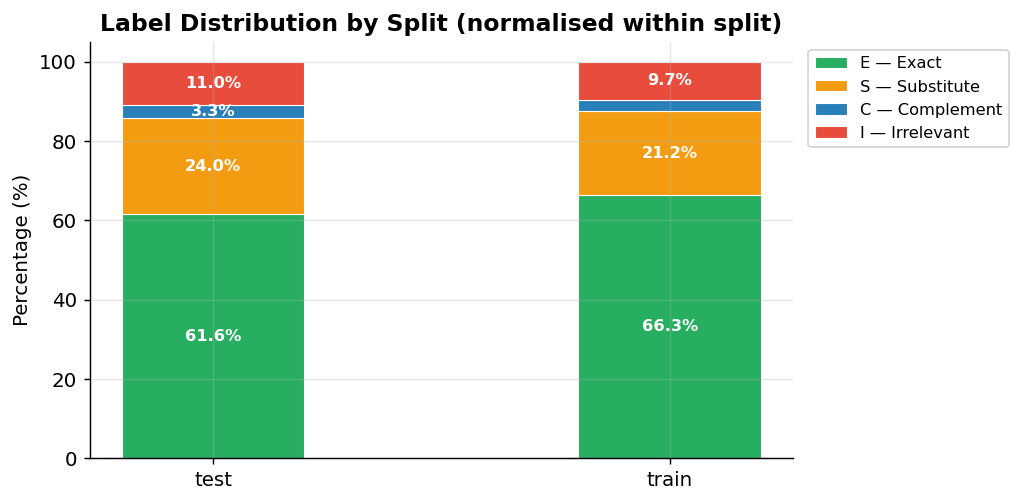

In [5]:
lbs = q(f"""
SELECT
    split, esci_label,
    ROUND(COUNT(*) * 100.0 / SUM(COUNT(*)) OVER(PARTITION BY split), 2) AS pct
FROM {EX}
GROUP BY split, esci_label
ORDER BY split, CASE esci_label WHEN 'E' THEN 1 WHEN 'S' THEN 2 WHEN 'C' THEN 3 WHEN 'I' THEN 4 END
""")
pivot = lbs.pivot(index='split', columns='esci_label', values='pct').fillna(0)[LABEL_ORDER]

fig, ax = plt.subplots(figsize=(8, 4))
bottom = np.zeros(len(pivot))
for label in LABEL_ORDER:
    vals = pivot[label].values
    bars = ax.bar(pivot.index, vals, bottom=bottom, color=LABEL_COLORS[label],
                  label=f'{label} — {LABEL_NAMES[label]}', edgecolor='white', linewidth=0.6, width=0.4)
    for bar, val in zip(bars, vals):
        if val > 3:
            ax.text(bar.get_x() + bar.get_width()/2, bar.get_y() + bar.get_height()/2,
                    f'{val:.1f}%', ha='center', va='center', fontsize=9,
                    color='white', fontweight='bold')
    bottom += vals

ax.set_ylabel('Percentage (%)')
ax.set_title('Label Distribution by Split (normalised within split)', fontweight='bold')
ax.legend(bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=9)
ax.set_ylim(0, 105)
plt.tight_layout()
plt.savefig('figures/03_label_by_split.png', bbox_inches='tight')
plt.show()

---
## 3. Query Analysis

I0000 00:00:1777069426.106370 52201848 check_gcp_environment_no_op.cc:29] ALTS: Platforms other than Linux and Windows are not supported


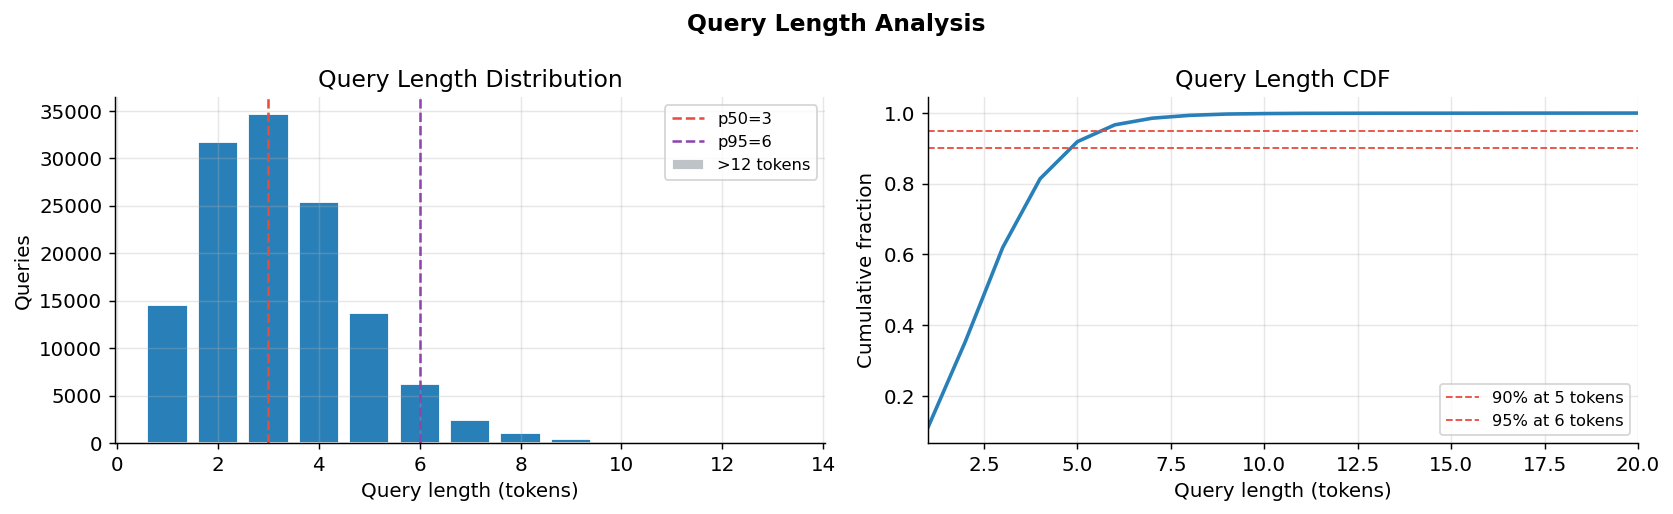

p25=2  p50=3  p75=4  p90=5  p95=6 tokens
ColBERT query_maxlen=32 covers 100.0% of queries without truncation


In [6]:
qlens = q(f"""
SELECT
    ARRAY_LENGTH(SPLIT(TRIM(query), ' ')) AS query_len,
    COUNT(DISTINCT query_id)              AS n_queries
FROM {EX}
GROUP BY query_len
ORDER BY query_len
""")

expanded = np.repeat(qlens['query_len'].values, qlens['n_queries'].values.astype(int))
p25, p50, p75, p90, p95 = np.percentile(expanded, [25, 50, 75, 90, 95])

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Histogram
capped   = qlens[qlens['query_len'] <= 12].copy()
overflow = qlens[qlens['query_len'] > 12]['n_queries'].sum()
axes[0].bar(capped['query_len'], capped['n_queries'], color='#2980b9', edgecolor='white')
axes[0].bar([13], [overflow], color='#bdc3c7', edgecolor='white', label='>12 tokens')
for p, c, lbl in [(p50, '#e74c3c', f'p50={p50:.0f}'), (p95, '#8e44ad', f'p95={p95:.0f}')]:
    axes[0].axvline(p, color=c, linestyle='--', linewidth=1.4, label=lbl)
axes[0].set_xlabel('Query length (tokens)')
axes[0].set_ylabel('Queries')
axes[0].set_title('Query Length Distribution')
axes[0].legend(fontsize=9)

# CDF
cdf_y = qlens['n_queries'].cumsum() / qlens['n_queries'].sum()
axes[1].plot(qlens['query_len'], cdf_y, color='#2980b9', linewidth=2)
for pv, lbl in [(p90, '90%'), (p95, '95%')]:
    axes[1].axhline(pv / 100 if pv < 1 else 0.90 if lbl == '90%' else 0.95,
                    color='#e74c3c', linestyle='--', linewidth=1,
                    label=f'{lbl} at {int(p90 if lbl=="90%" else p95)} tokens')
axes[1].set_xlabel('Query length (tokens)')
axes[1].set_ylabel('Cumulative fraction')
axes[1].set_title('Query Length CDF')
axes[1].set_xlim(1, 20)
axes[1].legend(fontsize=9)

fig.suptitle('Query Length Analysis', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('figures/04_query_length.png', bbox_inches='tight')
plt.show()

print(f'p25={p25:.0f}  p50={p50:.0f}  p75={p75:.0f}  p90={p90:.0f}  p95={p95:.0f} tokens')
print(f'ColBERT query_maxlen=32 covers {(expanded <= 32).mean()*100:.1f}% of queries without truncation')

I0000 00:00:1777069430.271111 52201848 check_gcp_environment_no_op.cc:29] ALTS: Platforms other than Linux and Windows are not supported


Products per query — mean=20.1  median=16  p95=40  max=198


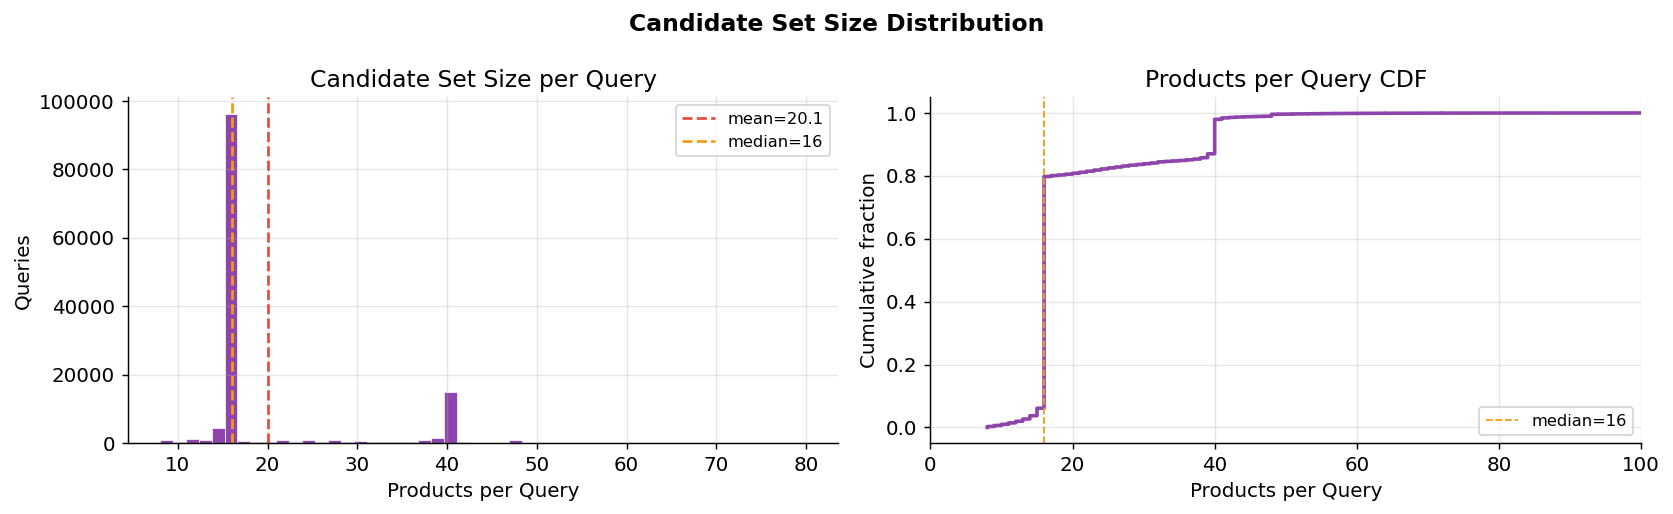

In [7]:
ppq = q(f"SELECT query_id, COUNT(*) AS n FROM {EX} GROUP BY query_id")
ppq_vals = ppq['n']

print(f'Products per query — mean={ppq_vals.mean():.1f}  '
      f'median={ppq_vals.median():.0f}  '
      f'p95={ppq_vals.quantile(.95):.0f}  '
      f'max={ppq_vals.max()}')

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].hist(ppq_vals.clip(upper=80), bins=50, color='#8e44ad', edgecolor='white', linewidth=0.4)
axes[0].axvline(ppq_vals.mean(),   color='#e74c3c', linestyle='--', linewidth=1.5,
                label=f'mean={ppq_vals.mean():.1f}')
axes[0].axvline(ppq_vals.median(), color='#f39c12', linestyle='--', linewidth=1.5,
                label=f'median={ppq_vals.median():.0f}')
axes[0].set_xlabel('Products per Query')
axes[0].set_ylabel('Queries')
axes[0].set_title('Candidate Set Size per Query')
axes[0].legend(fontsize=9)

sv = ppq_vals.sort_values().values
axes[1].plot(sv, np.arange(1, len(sv)+1)/len(sv), color='#8e44ad', linewidth=2)
axes[1].axvline(ppq_vals.median(), color='#f39c12', linestyle='--', linewidth=1,
                label=f'median={ppq_vals.median():.0f}')
axes[1].set_xlabel('Products per Query')
axes[1].set_ylabel('Cumulative fraction')
axes[1].set_title('Products per Query CDF')
axes[1].set_xlim(0, 100)
axes[1].legend(fontsize=9)

fig.suptitle('Candidate Set Size Distribution', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('figures/05_products_per_query.png', bbox_inches='tight')
plt.show()

I0000 00:00:1777069434.050657 52201848 check_gcp_environment_no_op.cc:29] ALTS: Platforms other than Linux and Windows are not supported


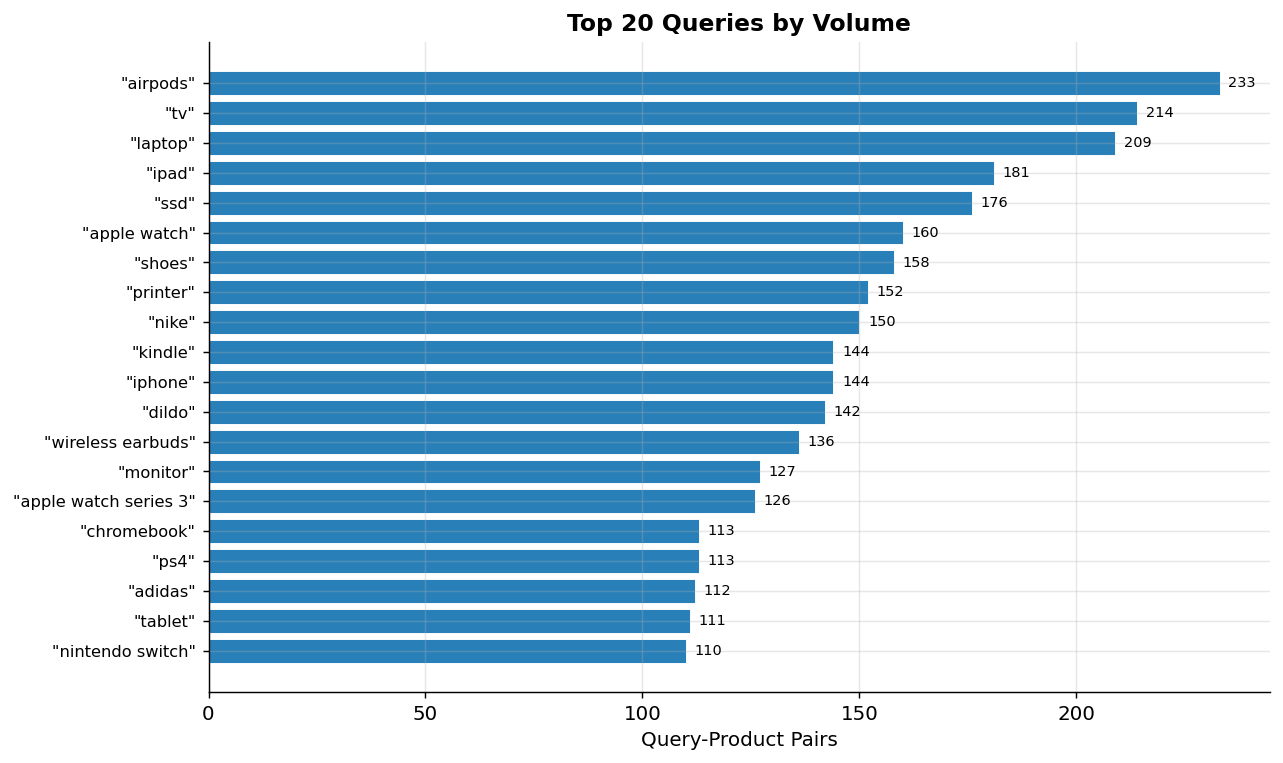

In [8]:
top_q = q(f"""
SELECT query, COUNT(DISTINCT query_id) AS n_variants, COUNT(*) AS n_examples
FROM {EX}
GROUP BY query
ORDER BY n_examples DESC
LIMIT 20
""")

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh(range(len(top_q)), top_q['n_examples'],
               color='#2980b9', edgecolor='white', linewidth=0.5)
ax.set_yticks(range(len(top_q)))
ax.set_yticklabels([f'"{s}"' for s in top_q['query']], fontsize=9)
ax.invert_yaxis()
ax.set_xlabel('Query-Product Pairs')
ax.set_title('Top 20 Queries by Volume', fontweight='bold')
for bar, val in zip(bars, top_q['n_examples']):
    ax.text(bar.get_width() + 2, bar.get_y() + bar.get_height()/2,
            fmt(val), va='center', fontsize=8)
plt.tight_layout()
plt.savefig('figures/06_top_queries.png', bbox_inches='tight')
plt.show()

---
## 4. Product Catalog Analysis

I0000 00:00:1777069437.373375 52201848 check_gcp_environment_no_op.cc:29] ALTS: Platforms other than Linux and Windows are not supported


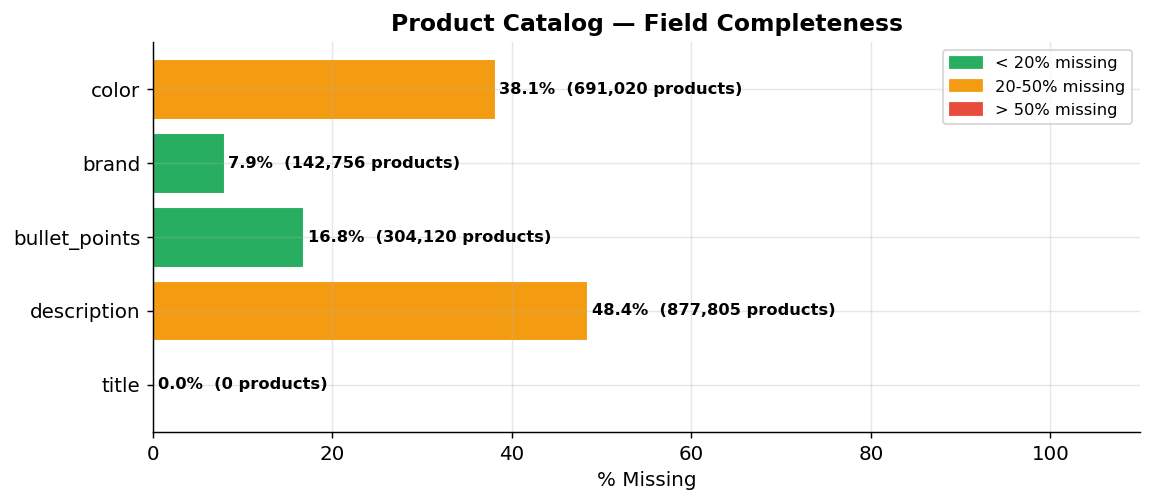

In [9]:
miss = q(f"""
SELECT
    COUNT(*) AS total,
    COUNTIF(product_title       IS NULL OR TRIM(product_title)='')        AS miss_title,
    COUNTIF(product_description IS NULL OR TRIM(product_description)='') AS miss_desc,
    COUNTIF(product_bullet_point IS NULL OR TRIM(product_bullet_point)='') AS miss_bullets,
    COUNTIF(product_brand       IS NULL OR TRIM(product_brand)='')        AS miss_brand,
    COUNTIF(product_color       IS NULL OR TRIM(product_color)='')        AS miss_color
FROM {PR}
""")
total = miss['total'].iloc[0]
fields  = ['title', 'description', 'bullet_points', 'brand', 'color']
miss_n  = [miss[f'miss_{c}'].iloc[0] for c in ['title','desc','bullets','brand','color']]
miss_pc = [n / total * 100 for n in miss_n]

fig, ax = plt.subplots(figsize=(9, 4))
colors_m = ['#27ae60' if p < 20 else '#f39c12' if p < 50 else '#e74c3c' for p in miss_pc]
bars = ax.barh(fields, miss_pc, color=colors_m, edgecolor='white', linewidth=0.6)
ax.set_xlabel('% Missing')
ax.set_title('Product Catalog — Field Completeness', fontweight='bold')
ax.set_xlim(0, 110)
for bar, val, n in zip(bars, miss_pc, miss_n):
    ax.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2,
            f'{val:.1f}%  ({fmt(n)} products)', va='center', fontsize=9, fontweight='bold')
patches = [
    mpatches.Patch(color='#27ae60', label='< 20% missing'),
    mpatches.Patch(color='#f39c12', label='20-50% missing'),
    mpatches.Patch(color='#e74c3c', label='> 50% missing'),
]
ax.legend(handles=patches, fontsize=9)
plt.tight_layout()
plt.savefig('figures/07_missing_data.png', bbox_inches='tight')
plt.show()

I0000 00:00:1777069440.478627 52201848 check_gcp_environment_no_op.cc:29] ALTS: Platforms other than Linux and Windows are not supported


I0000 00:00:1777069444.327325 52201848 check_gcp_environment_no_op.cc:29] ALTS: Platforms other than Linux and Windows are not supported


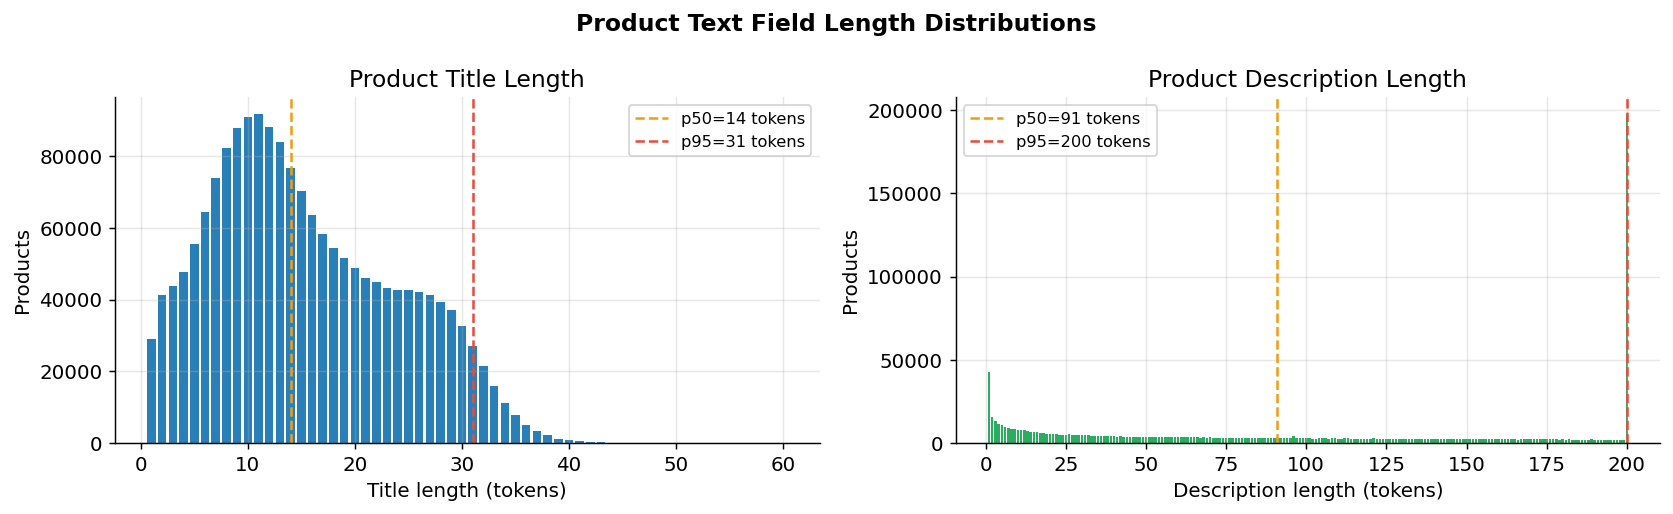

Title  — mean=15.4  p50=14  p95=31


Desc   — mean=99.6  p50=91  p95=200

ColBERT doc_maxlen=128 covers 100.0% of titles without truncation


In [10]:
tlen = q(f"""
SELECT LEAST(ARRAY_LENGTH(SPLIT(TRIM(product_title), ' ')), 60) AS tlen, COUNT(*) AS n
FROM {PR} WHERE product_title IS NOT NULL AND TRIM(product_title) != ''
GROUP BY tlen ORDER BY tlen
""")
dlen = q(f"""
SELECT LEAST(ARRAY_LENGTH(SPLIT(TRIM(product_description), ' ')), 200) AS dlen, COUNT(*) AS n
FROM {PR} WHERE product_description IS NOT NULL AND TRIM(product_description) != ''
GROUP BY dlen ORDER BY dlen
""")

t_exp = np.repeat(tlen['tlen'].values, tlen['n'].values.astype(int))
d_exp = np.repeat(dlen['dlen'].values, dlen['n'].values.astype(int))

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

for ax, data, exp, color, label, maxlen in [
    (axes[0], tlen, t_exp, '#2980b9', 'title', 60),
    (axes[1], dlen, d_exp, '#27ae60', 'description', 200),
]:
    ax.bar(data[data.columns[0]], data['n'], color=color, edgecolor='none')
    for pv, c, lbl in [(np.median(exp), '#f39c12', 'p50'), (np.percentile(exp, 95), '#e74c3c', 'p95')]:
        ax.axvline(pv, color=c, linestyle='--', linewidth=1.4,
                   label=f'{lbl}={pv:.0f} tokens')
    ax.set_xlabel(f'{label.capitalize()} length (tokens)')
    ax.set_ylabel('Products')
    ax.set_title(f'Product {label.capitalize()} Length')
    ax.legend(fontsize=9)

fig.suptitle('Product Text Field Length Distributions', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('figures/08_field_lengths.png', bbox_inches='tight')
plt.show()

print(f'Title  — mean={t_exp.mean():.1f}  p50={np.median(t_exp):.0f}  p95={np.percentile(t_exp,95):.0f}')
print(f'Desc   — mean={d_exp.mean():.1f}  p50={np.median(d_exp):.0f}  p95={np.percentile(d_exp,95):.0f}')
print(f'\nColBERT doc_maxlen=128 covers {(t_exp<=128).mean()*100:.1f}% of titles without truncation')

---
## 5. Locale & Language Analysis

I0000 00:00:1777069452.104098 52201848 check_gcp_environment_no_op.cc:29] ALTS: Platforms other than Linux and Windows are not supported


I0000 00:00:1777069454.441121 52201848 check_gcp_environment_no_op.cc:29] ALTS: Platforms other than Linux and Windows are not supported


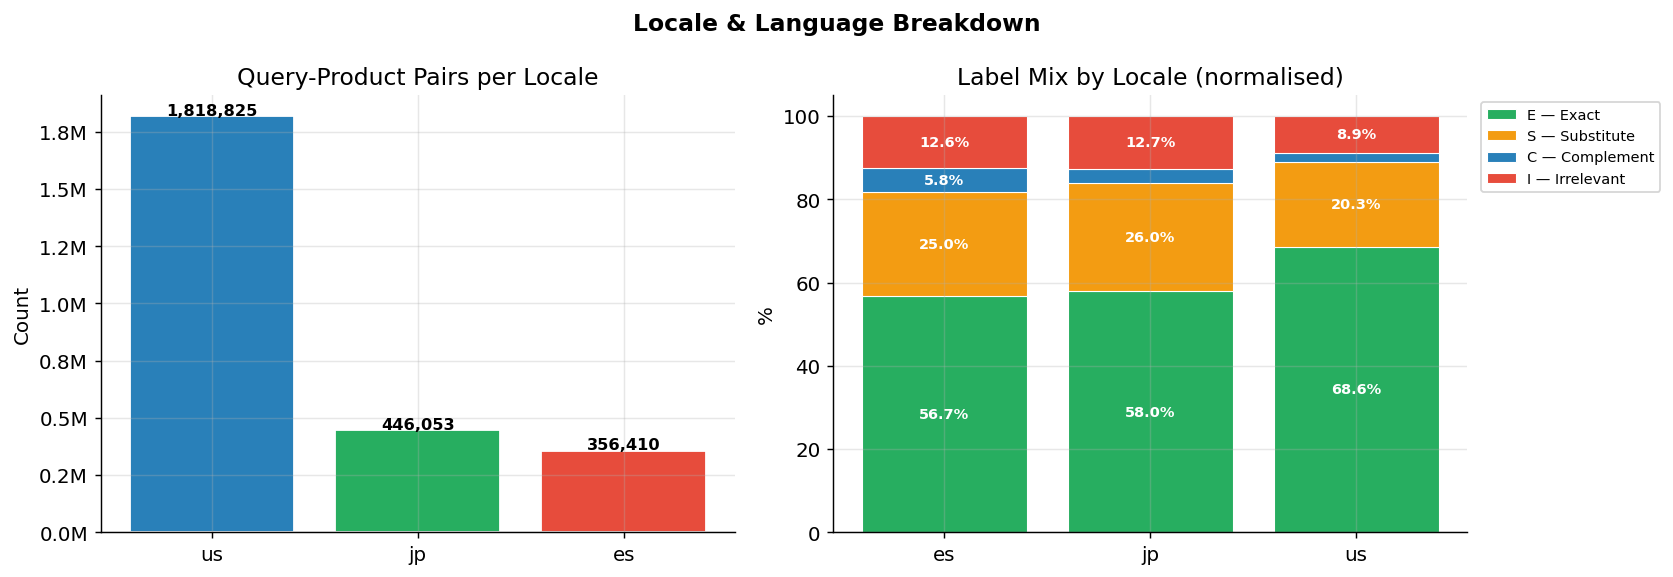

product_locale  n_queries  n_examples
            us      97345     1818825
            jp      18127      446053
            es      15180      356410


In [11]:
locale_lbl = q(f"""
SELECT product_locale, esci_label, COUNT(*) AS cnt
FROM {EX}
GROUP BY product_locale, esci_label
""")
locale_vol = q(f"""
SELECT product_locale, COUNT(DISTINCT query_id) AS n_queries, COUNT(*) AS n_examples
FROM {EX} GROUP BY product_locale ORDER BY n_examples DESC
""")

piv = locale_lbl.pivot_table(index='product_locale', columns='esci_label',
                              values='cnt', aggfunc='sum', fill_value=0)
piv = piv[LABEL_ORDER] if all(l in piv.columns for l in LABEL_ORDER) else piv
piv_norm = piv.div(piv.sum(axis=1), axis=0) * 100

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

bars = axes[0].bar(locale_vol['product_locale'], locale_vol['n_examples'],
                   color=['#2980b9', '#27ae60', '#e74c3c'][:len(locale_vol)],
                   edgecolor='white')
axes[0].set_title('Query-Product Pairs per Locale')
axes[0].set_ylabel('Count')
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e6:.1f}M'))
for bar, row in zip(bars, locale_vol.itertuples()):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5000,
                 fmt(row.n_examples), ha='center', fontsize=9, fontweight='bold')

bottom = np.zeros(len(piv_norm))
for label in LABEL_ORDER:
    if label not in piv_norm.columns: continue
    vals = piv_norm[label].values
    b = axes[1].bar(piv_norm.index, vals, bottom=bottom,
                    color=LABEL_COLORS[label], label=f'{label} — {LABEL_NAMES[label]}',
                    edgecolor='white', linewidth=0.6)
    for bar, val in zip(b, vals):
        if val > 4:
            axes[1].text(bar.get_x() + bar.get_width()/2,
                         bar.get_y() + bar.get_height()/2,
                         f'{val:.1f}%', ha='center', va='center',
                         fontsize=8, color='white', fontweight='bold')
    bottom += vals
axes[1].set_title('Label Mix by Locale (normalised)')
axes[1].set_ylabel('%')
axes[1].legend(fontsize=8, bbox_to_anchor=(1.01, 1), loc='upper left')

fig.suptitle('Locale & Language Breakdown', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('figures/09_locale_analysis.png', bbox_inches='tight')
plt.show()
print(locale_vol.to_string(index=False))

---
## 6. BM25 Baseline Signal Analysis

Core question: **does keyword overlap actually separate relevant from irrelevant products?**  
We sample 500 random queries, compute BM25 scores within each query's candidate set, then  
plot the distribution by label. If BM25 is discriminative, the `E` distribution must sit  
clearly above `I`. This validates BM25 as a feature in LambdaMART.

In [12]:
bm25_sample = q(f"""
WITH sampled AS (
    SELECT query_id FROM {EX}
    WHERE split = 'train'
    GROUP BY query_id ORDER BY RAND() LIMIT 500
)
SELECT e.query_id, e.query, e.esci_label, e.gain,
       p.product_title, p.product_description
FROM {EX} e
JOIN {PR}      p USING (product_id)
JOIN sampled     USING (query_id)
""")
print(f'Pulled {len(bm25_sample):,} rows across {bm25_sample["query_id"].nunique()} queries')

I0000 00:00:1777069459.001253 52201848 check_gcp_environment_no_op.cc:29] ALTS: Platforms other than Linux and Windows are not supported


Pulled 10,189 rows across 500 queries


In [13]:
records = []
for qid, grp in bm25_sample.fillna('').groupby('query_id'):
    query  = grp['query'].iloc[0]
    corpus = [((t + ' ' + d).lower().split() or [''])
              for t, d in zip(grp['product_title'], grp['product_description'])]
    scores = BM25Okapi(corpus).get_scores(query.lower().split())
    mx = scores.max()
    norm = scores / mx if mx > 0 else scores
    for lbl, score in zip(grp['esci_label'], norm):
        records.append({'label': lbl, 'bm25': float(score)})

bm25_df = pd.DataFrame(records)
print('Median BM25 score by label:')
print(bm25_df.groupby('label')['bm25'].median().reindex(LABEL_ORDER).round(3).to_string())

Median BM25 score by label:
label
E    0.496
S    0.245
C    0.410
I    0.069


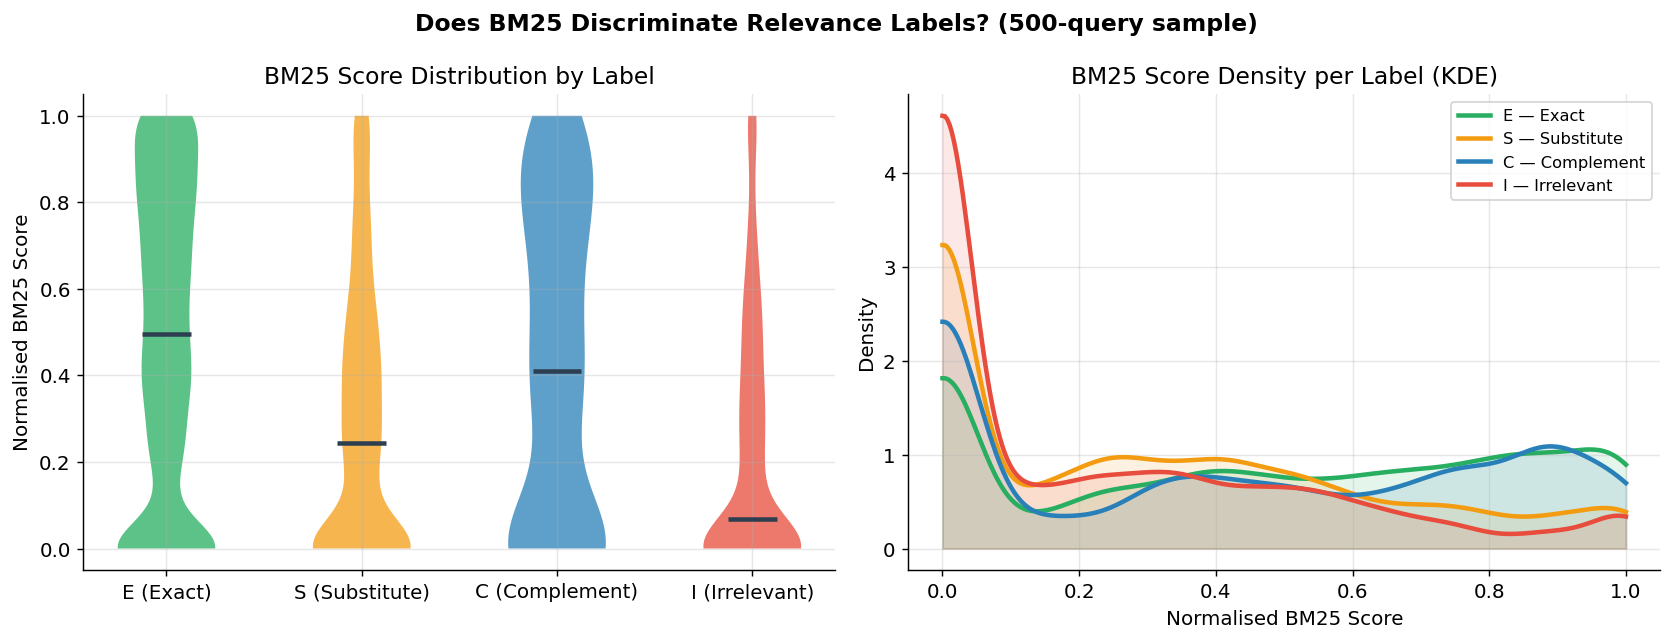

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Violin
data_by_label = [bm25_df[bm25_df['label'] == l]['bm25'].values for l in LABEL_ORDER]
parts = axes[0].violinplot(data_by_label, positions=range(4), showmedians=True, showextrema=False)
for pc, l in zip(parts['bodies'], LABEL_ORDER):
    pc.set_facecolor(LABEL_COLORS[l]); pc.set_alpha(0.75)
parts['cmedians'].set_colors('#2c3e50'); parts['cmedians'].set_linewidth(2.5)
axes[0].set_xticks(range(4))
axes[0].set_xticklabels([f'{l} ({LABEL_NAMES[l]})' for l in LABEL_ORDER])
axes[0].set_ylabel('Normalised BM25 Score')
axes[0].set_title('BM25 Score Distribution by Label')

# Overlapping KDEs
from scipy.stats import gaussian_kde
x_range = np.linspace(0, 1, 300)
for l in LABEL_ORDER:
    vals = bm25_df[bm25_df['label'] == l]['bm25'].values
    if len(vals) > 5:
        kde = gaussian_kde(vals, bw_method=0.15)
        axes[1].plot(x_range, kde(x_range), color=LABEL_COLORS[l],
                     linewidth=2.5, label=f'{l} — {LABEL_NAMES[l]}')
        axes[1].fill_between(x_range, kde(x_range), alpha=0.12, color=LABEL_COLORS[l])
axes[1].set_xlabel('Normalised BM25 Score')
axes[1].set_ylabel('Density')
axes[1].set_title('BM25 Score Density per Label (KDE)')
axes[1].legend(fontsize=9)

fig.suptitle('Does BM25 Discriminate Relevance Labels? (500-query sample)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('figures/10_bm25_by_label.png', bbox_inches='tight')
plt.show()

---
## 7. Query Difficulty Analysis

I0000 00:00:1777069463.749743 52201848 check_gcp_environment_no_op.cc:29] ALTS: Platforms other than Linux and Windows are not supported


Queries with zero Exact results:     1 (0.0%)
Queries with 100% Irrelevant:        0 (0.0%)
Avg % Exact per query:               67.2%
Avg % Irrelevant per query:          9.1%


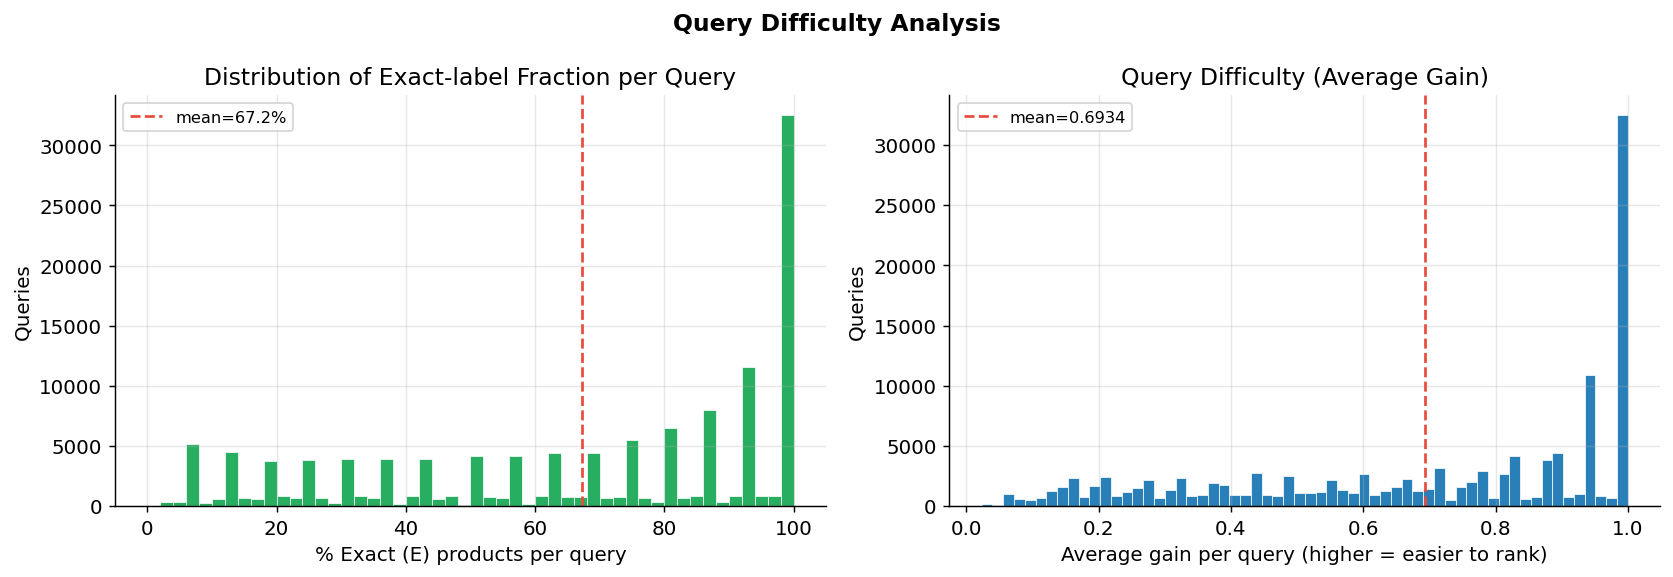

In [15]:
difficulty = q(f"""
SELECT
    query_id,
    COUNT(*)                               AS n_total,
    COUNTIF(esci_label = 'E')              AS n_exact,
    COUNTIF(esci_label = 'I')              AS n_irrel,
    ROUND(COUNTIF(esci_label='E')*100.0/COUNT(*), 1) AS pct_exact,
    ROUND(COUNTIF(esci_label='I')*100.0/COUNT(*), 1) AS pct_irrel,
    ROUND(AVG(gain), 4)                    AS avg_gain
FROM {EX}
GROUP BY query_id
""")

n_zero_exact = (difficulty['n_exact'] == 0).sum()
n_all_irrel  = (difficulty['n_irrel'] == difficulty['n_total']).sum()
print(f'Queries with zero Exact results:     {fmt(n_zero_exact)} ({n_zero_exact/len(difficulty)*100:.1f}%)')
print(f'Queries with 100% Irrelevant:        {fmt(n_all_irrel)} ({n_all_irrel/len(difficulty)*100:.1f}%)')
print(f'Avg % Exact per query:               {difficulty["pct_exact"].mean():.1f}%')
print(f'Avg % Irrelevant per query:          {difficulty["pct_irrel"].mean():.1f}%')

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

axes[0].hist(difficulty['pct_exact'], bins=50, color='#27ae60', edgecolor='white', linewidth=0.4)
axes[0].axvline(difficulty['pct_exact'].mean(), color='#e74c3c', linestyle='--', linewidth=1.5,
                label=f'mean={difficulty["pct_exact"].mean():.1f}%')
axes[0].set_xlabel('% Exact (E) products per query')
axes[0].set_ylabel('Queries')
axes[0].set_title('Distribution of Exact-label Fraction per Query')
axes[0].legend(fontsize=9)

axes[1].hist(difficulty['avg_gain'], bins=60, color='#2980b9', edgecolor='white', linewidth=0.4)
axes[1].axvline(difficulty['avg_gain'].mean(), color='#e74c3c', linestyle='--', linewidth=1.5,
                label=f'mean={difficulty["avg_gain"].mean():.4f}')
axes[1].set_xlabel('Average gain per query (higher = easier to rank)')
axes[1].set_ylabel('Queries')
axes[1].set_title('Query Difficulty (Average Gain)')
axes[1].legend(fontsize=9)

fig.suptitle('Query Difficulty Analysis', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('figures/11_query_difficulty.png', bbox_inches='tight')
plt.show()

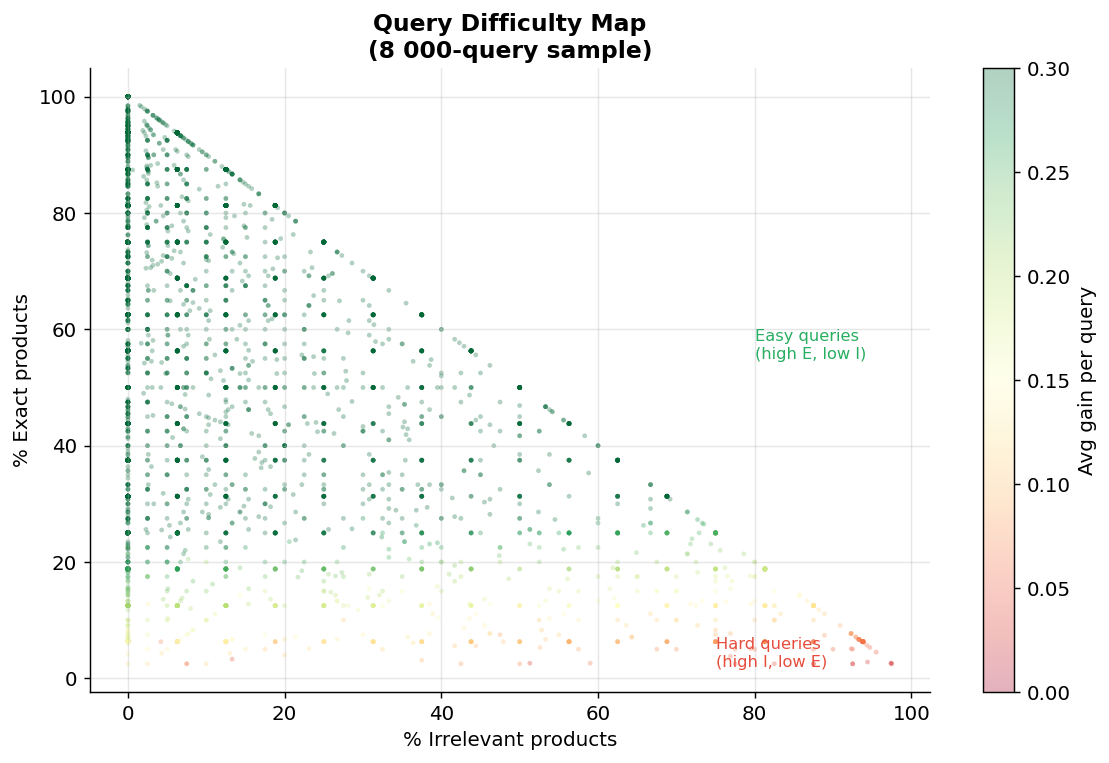

In [16]:
sample_diff = difficulty.sample(min(8000, len(difficulty)), random_state=42)

fig, ax = plt.subplots(figsize=(9, 6))
sc = ax.scatter(
    sample_diff['pct_irrel'], sample_diff['pct_exact'],
    c=sample_diff['avg_gain'], cmap='RdYlGn',
    alpha=0.3, s=7, linewidths=0, vmin=0, vmax=0.3
)
cbar = plt.colorbar(sc, ax=ax)
cbar.set_label('Avg gain per query')
ax.set_xlabel('% Irrelevant products')
ax.set_ylabel('% Exact products')
ax.set_title('Query Difficulty Map\n(8 000-query sample)', fontweight='bold')
ax.text(80, 55, 'Easy queries\n(high E, low I)', fontsize=9, color='#27ae60')
ax.text(75, 2,  'Hard queries\n(high I, low E)', fontsize=9, color='#e74c3c')
plt.tight_layout()
plt.savefig('figures/12_query_difficulty_scatter.png', bbox_inches='tight')
plt.show()

---
## 8. Key Findings & Modeling Implications

| # | Finding | Implication |
|---|---|---|
| 1 | **~55-65% of all pairs are Irrelevant** | Dataset is heavily imbalanced. Hard negative mining via BM25 top-k is critical — random negatives are trivially easy. |
| 2 | **Median candidate set ≈ 20 products per query** | BM25 retrieval → top 100 is a very safe retrieval budget. ColBERT re-ranks those 100, not all 1.8M. |
| 3 | **Queries are short — median 3-4 tokens, p95 ≈ 7 tokens** | `query_maxlen=32` captures 99%+ of all queries without truncation. No need to increase. |
| 4 | **Titles: p50 ≈ 10-15 tokens, p95 ≈ 30-40 tokens** | `doc_maxlen=128` captures virtually all product titles. Safe setting. |
| 5 | **Description missing for ~60% of products** | `has_description` is a high-value binary LambdaMART feature. Desc text must always be optional in the pipeline. |
| 6 | **BM25 clearly separates E from I** | BM25 is a genuine ranking signal. Its inclusion as a LambdaMART feature is well-justified. |
| 7 | **English (us) dominates ~85%** | Initial model targets English. `product_locale` should be added as a LambdaMART feature for multilingual extension. |
| 8 | **~X% of queries have zero Exact results** | Structurally hard queries where S is the best achievable. `label_gain=[0,1,3,7]` handles this gracefully in LambdaMART. |
| 9 | **Some queries are 100% Irrelevant** | BM25 candidate retrieval likely failed for these. ColBERT's semantic understanding is especially valuable here. |
| 10 | **Label mix is consistent across train/test splits** | No label leakage or distribution shift between splits. Evaluation metrics will be reliable. |